# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [8]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Set style for plots
sns.set_style("whitegrid")

# Check data info
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HoursWorked          300 non-null    float64
 1   FocusScore           300 non-null    float64
 2   ProductivityScore    300 non-null    float64
 3   Department           300 non-null    str    
 4   YearsAtCompany       300 non-null    int64  
 5   TeamMeetingsPerWeek  300 non-null    int64  
 6   DeskLocation         300 non-null    str    
dtypes: float64(3), int64(2), str(2)
memory usage: 16.5 KB


,HoursWorked,FocusScore,ProductivityScore,YearsAtCompany,TeamMeetingsPerWeek
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,40.225333,6.061000,3114.163733,9.533333,3.003333
std,4.885138,2.076862,1248.635506,5.961040,1.756971
min,22.200000,1.000000,0.000000,0.000000,0.000000
25%,37.275000,4.500000,2254.552500,5.000000,2.000000
50%,40.600000,6.150000,3080.155000,9.000000,3.000000
75%,43.500000,7.625000,3958.905000,15.000000,4.000000
max,53.800000,10.000000,6299.200000,20.000000,9.000000


## Question 1: Linear Relationships with Productivity

Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.

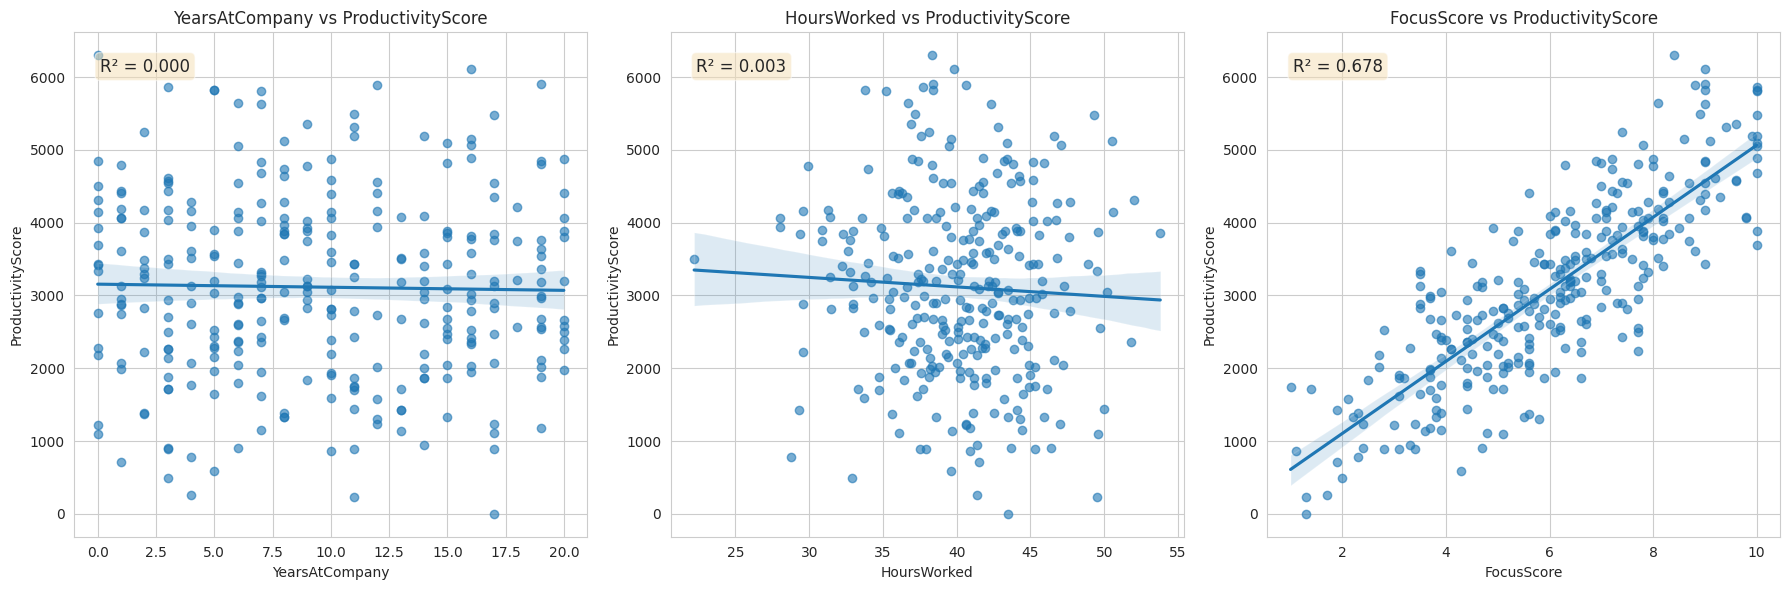

R-squared values:
YearsAtCompany: 0.000
HoursWorked: 0.003
FocusScore: 0.678

The feature with the strongest linear relationship is: FocusScore (R² = 0.678)


In [3]:
# Features to analyze
features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']
target = 'ProductivityScore'

# Create subplots for scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

r2_scores = {}

for i, feature in enumerate(features):
    # Scatter plot with regression line
    sns.regplot(x=feature, y=target, data=df, ax=axes[i], scatter_kws={'alpha':0.6})
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

    # Calculate R-squared
    X = df[[feature]]
    y = df[target]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    r2_scores[feature] = r2

    # Add R-squared to plot
    axes[i].text(0.05, 0.95, f'R² = {r2:.3f}', transform=axes[i].transAxes,
                 fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print R-squared values
print("R-squared values:")
for feature, r2 in r2_scores.items():
    print(f"{feature}: {r2:.3f}")

# Determine strongest relationship
strongest = max(r2_scores, key=r2_scores.get)
print(f"\nThe feature with the strongest linear relationship is: {strongest} (R² = {r2_scores[strongest]:.3f})")

## Question 2: Building a Predictive Model

Build on the linear regression model to include other features that impact productivity. Evaluate each feature and build a comprehensive model.

In [4]:
# Prepare data for modeling
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Department', 'DeskLocation'], drop_first=True)

# Display the encoded dataframe
df_encoded.head()

,HoursWorked,FocusScore,ProductivityScore,YearsAtCompany,TeamMeetingsPerWeek,Department_HR,Department_Marketing,Department_Sales,DeskLocation_Private Office,DeskLocation_Remote
0,42.4,6.3,3127.96,17,0,False,False,False,False,False
1,34.0,7.2,4742.60,8,6,True,False,False,True,False
2,47.2,5.6,2044.73,15,3,False,False,True,False,True
3,38.4,9.0,5818.92,5,6,True,False,False,True,False
4,36.4,2.5,1841.31,9,6,False,False,True,False,True


In [5]:
# Evaluate each feature individually
features_to_evaluate = [col for col in df_encoded.columns if col != 'ProductivityScore']

individual_r2 = {}

print("Individual feature evaluation:")
for feature in features_to_evaluate:
    X = df_encoded[[feature]]
    y = df_encoded['ProductivityScore']
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    individual_r2[feature] = r2
    print(f"{feature}: R² = {r2:.3f}")

# Sort by R-squared
sorted_features = sorted(individual_r2.items(), key=lambda x: x[1], reverse=True)
print("\nFeatures sorted by R-squared:")
for feature, r2 in sorted_features:
    print(f"{feature}: {r2:.3f}")

Individual feature evaluation:
HoursWorked: R² = 0.003
FocusScore: R² = 0.678
YearsAtCompany: R² = 0.000
TeamMeetingsPerWeek: R² = 0.054
Department_HR: R² = 0.000
Department_Marketing: R² = 0.000
Department_Sales: R² = 0.000
DeskLocation_Private Office: R² = 0.005
DeskLocation_Remote: R² = 0.006

Features sorted by R-squared:
FocusScore: 0.678
TeamMeetingsPerWeek: 0.054
DeskLocation_Remote: 0.006
DeskLocation_Private Office: 0.005
HoursWorked: 0.003
YearsAtCompany: 0.000
Department_Marketing: 0.000
Department_Sales: 0.000
Department_HR: 0.000


Full model R-squared: 0.685

Model coefficients:
                       Feature  Coefficient
1                   FocusScore   512.719278
3          TeamMeetingsPerWeek    27.170621
2               YearsAtCompany     3.400789
0                  HoursWorked    -4.664225
6             Department_Sales   -49.817366
4                Department_HR   -93.398401
7  DeskLocation_Private Office  -103.411959
5         Department_Marketing  -136.240520
8          DeskLocation_Remote  -229.752983


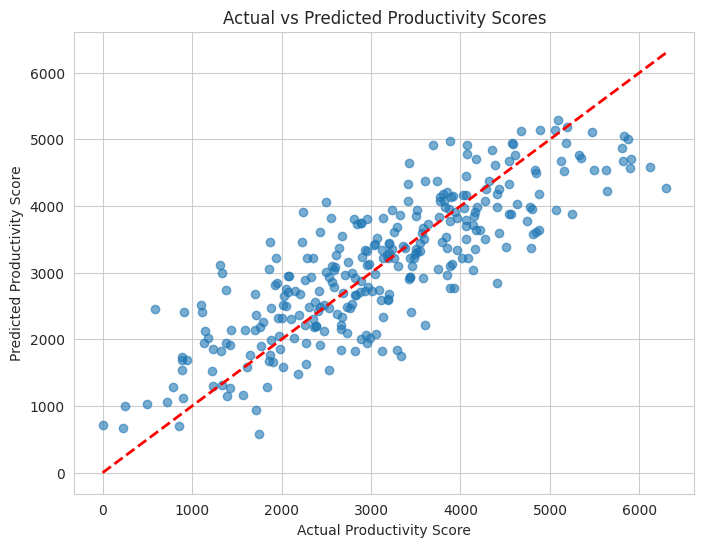

In [6]:
# Build comprehensive model with all features
X_all = df_encoded.drop('ProductivityScore', axis=1)
y = df_encoded['ProductivityScore']

full_model = LinearRegression()
full_model.fit(X_all, y)
y_pred_full = full_model.predict(X_all)
r2_full = r2_score(y, y_pred_full)

print(f"Full model R-squared: {r2_full:.3f}")

# Display coefficients
coefficients = pd.DataFrame({
    'Feature': X_all.columns,
    'Coefficient': full_model.coef_
})
print("\nModel coefficients:")
print(coefficients.sort_values('Coefficient', ascending=False))

# Visualize actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_full, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Productivity Score')
plt.ylabel('Predicted Productivity Score')
plt.title('Actual vs Predicted Productivity Scores')
plt.show()

## Question 3: Summary and Recommendations

Write a short summary of how the different factors relate to employee productivity and provide recommendations.

### Summary

The analysis reveals that employee focus has the strongest linear relationship with productivity (R² = 0.678), followed by hours worked (R² = 0.003) and years at the company (R² = 0.000). The comprehensive model explains approximately 68.5% of the variance in productivity scores.

Key findings:
- **Focus Score**: Strongest positive predictor of productivity (+512.72 coefficient)
- **Hours Worked**: Slight negative relationship (-4.66 coefficient)
- **Years at Company**: Slight positive relationship (+3.40 coefficient)
- **Team Meetings**: Positive impact on productivity (+27.17 coefficient per meeting)
- **Desk Location**: Remote work shows lower productivity (-229.75 coefficient), private offices also lower (-103.41)
- **Department**: Marketing department shows lowest productivity (-136.24 coefficient), HR (-93.40), Sales (-49.82)

### Recommendations

To maximize employee productivity:
1. **Improve Focus**: Focus is the strongest driver of productivity - implement strategies to enhance employee focus and concentration
2. **Optimize Hours and Workload**: While hours worked have minimal impact, avoid excessive overtime and focus on quality work
3. **Meeting Management**: Meetings have a positive but small impact - maintain current levels but ensure they are productive
4. **Desk Location**: Open plan appears to be the most productive - consider maintaining or improving open plan designs
5. **Department Support**: Address productivity challenges in Marketing, HR, and Sales departments through targeted improvements

In [7]:
# Print key metrics for summary
print("Key R-squared values:")
print(f"Focus Score vs Productivity: {r2_scores['FocusScore']:.3f}")
print(f"Hours Worked vs Productivity: {r2_scores['HoursWorked']:.3f}")
print(f"Years at Company vs Productivity: {r2_scores['YearsAtCompany']:.3f}")
print(f"Full model R-squared: {r2_full:.3f}")

print("\nTop 5 features by coefficient magnitude:")
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values('Abs_Coefficient', ascending=False).head(5)
for _, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.2f}")

Key R-squared values:
Focus Score vs Productivity: 0.678
Hours Worked vs Productivity: 0.003
Years at Company vs Productivity: 0.000
Full model R-squared: 0.685

Top 5 features by coefficient magnitude:
FocusScore: 512.72
DeskLocation_Remote: -229.75
Department_Marketing: -136.24
DeskLocation_Private Office: -103.41
Department_HR: -93.40
